In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

observations= pd.read_csv('observations.csv')
species= pd.read_csv('species_info.csv')

print(observations.head())
print(species.head())
print()
print(observations.columns)
print(species.columns)

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic 

In [8]:
print(observations.info())
print()
print(species.info())
print(species.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None
              category    scientific_name        common_names  \
count             5824               5824                5824   
unique               7          

In [17]:
species['is_missing']= species['conservation_status'].isnull()
print(species['is_missing'].value_counts())
species.groupby('category')['is_missing'].mean()

is_missing
True     5633
False     191
Name: count, dtype: int64


category
Amphibian            0.912500
Bird                 0.848369
Fish                 0.913386
Mammal               0.822430
Nonvascular Plant    0.984985
Reptile              0.936709
Vascular Plant       0.989709
Name: is_missing, dtype: float64

In [ ]:
# The majority of species in the dataset do not have a conservation status,but the percentage of missing conservation status varies by category. For example, amphibians have a higher percentage of missing conservation status compared to mammals and birds.
species['conservation_status'].value_counts(dropna=False)

conservation_status
NaN                   5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

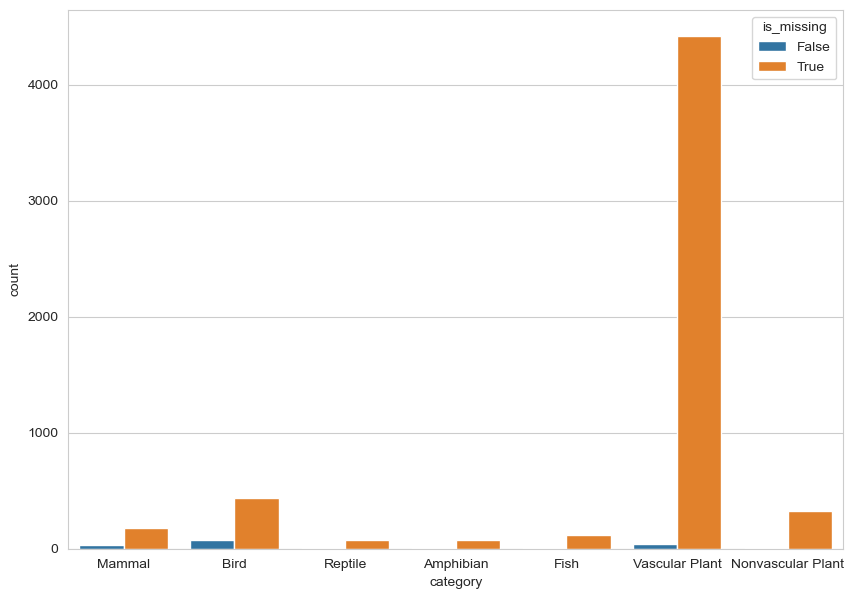

In [ ]:
#So using this information it is MAR and might be MNAR because the missingness is related to the category of the species, which is observed. However, it could also be MNAR if the missingness is related to unobserved factors that are not included in the dataset. Therefore, using domain knowledge we can clearly say it is MNAR because the conservation status of non-missing are related to the concern of the species so the missing are related to not concerned species which is not observed in the dataset.so we can say it is MNAR/ domain-driven missingness.
plt.figure(figsize=(10,7))
sns.countplot(x='category', hue='is_missing', data=species)

In [26]:
species['conservation_status'] = species['conservation_status'].fillna('no concern')
print(species['conservation_status'].value_counts())

conservation_status
no concern            5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64


In [27]:
print(species.duplicated().sum())
print(observations.duplicated().sum())

0
15


In [29]:
observations = observations.drop_duplicates()
print(observations.duplicated().sum())

0


In [31]:
print(species['category'].unique())
print(species['conservation_status'].unique())
print(observations['park_name'].unique())

['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']
['no concern' 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']
['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


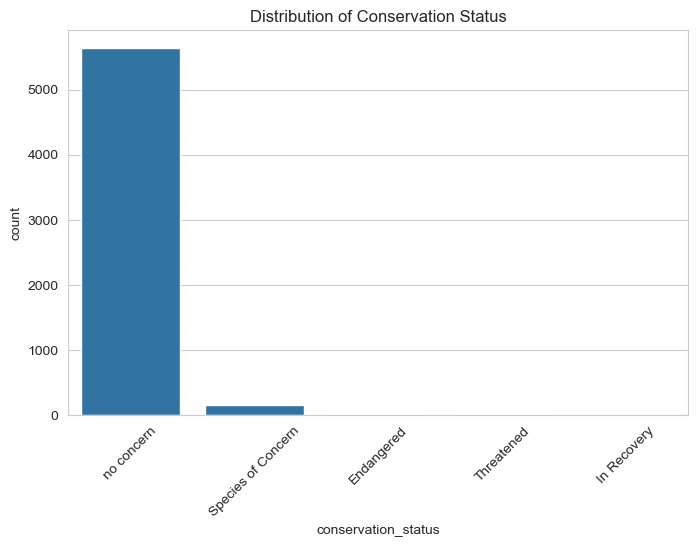

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=species, x='conservation_status',  order=species['conservation_status'].value_counts().index)
plt.title("Distribution of Conservation Status")
plt.xticks(rotation=45)
plt.show()

ANIMALS SHAPE: (1021, 5)
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  \
0                           Gapper's Red-Backed Vole          no concern   
1                              American Bison, Bison          no concern   
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          no concern   
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)          no concern   
4                                      Wapiti Or Elk          no concern   

   is_missing  
0        True  
1        True  
2        True  
3        True  
4        True  


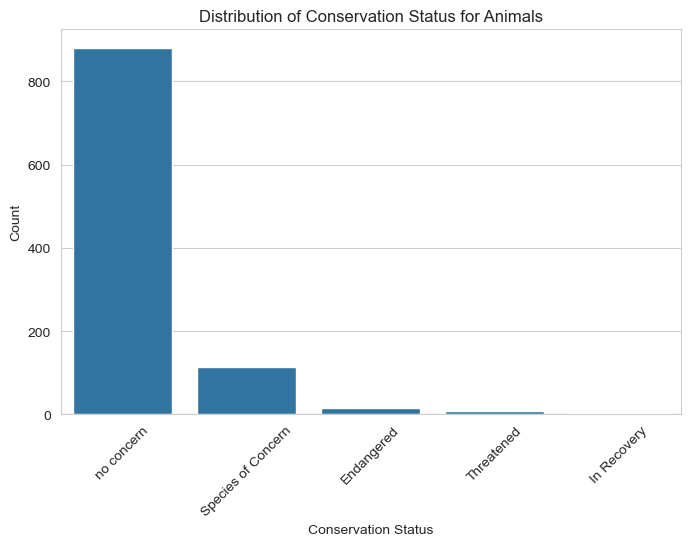

In [58]:
animals = species[species["category"].isin(["Mammal", "Bird", "Reptile", "Amphibian", "Fish"])].copy()

print("ANIMALS SHAPE:", animals.shape)
print(animals.head())

plt.figure(figsize=(8, 5))
sns.countplot(
    data=animals,
    x="conservation_status",
    order=animals["conservation_status"].value_counts().index
)
plt.title("Distribution of Conservation Status for Animals")
plt.xlabel("Conservation Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

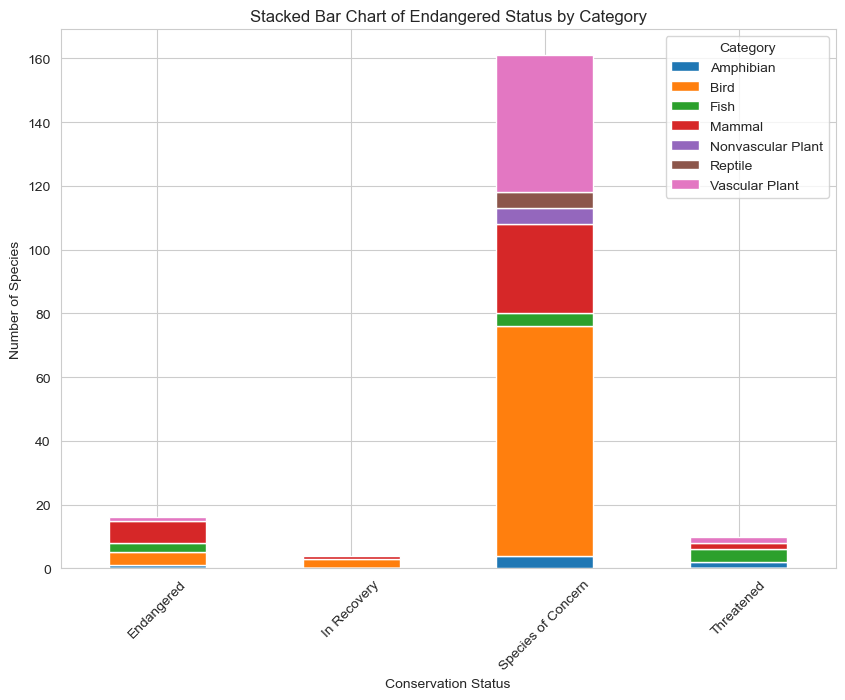

In [59]:
conservationCategory  = species[species['conservation_status'] != 'no concern']
category_counts= conservationCategory.groupby(['conservation_status', 'category'])['scientific_name'].count().unstack()
ax = category_counts.plot(kind='bar', stacked=True, figsize=(10,7))
ax.set_xticklabels( labels=category_counts.index, rotation=45)
ax.set_xlabel('Conservation Status')
ax.set_ylabel('Number of Species')
ax.set_title("Stacked Bar Chart of Endangered Status by Category")
ax.legend(title='Category')
plt.show()


In [69]:
species['is_protected'] = species['conservation_status'] != 'no concern'
category_counts = species.groupby(['category', 'is_protected']).scientific_name.nunique().reset_index()\
                                     .pivot(columns='is_protected',
                                      index='category',
                                      values='scientific_name')\
                        .reset_index()
category_counts.columns = ['category', 'not_protected', 'protected']

category_counts

,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


In [70]:
category_counts['percent_protected'] = category_counts.protected / \
                                      (category_counts.protected + category_counts.not_protected) * 100

category_counts

,category,not_protected,protected,percent_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


In [73]:
from scipy.stats import chi2_contingency
contingency1 = [[30,146], [75, 413]]
chi2_contingency(contingency1)



Chi2ContingencyResult(statistic=np.float64(0.1617014831654557), pvalue=np.float64(0.6875948096661336), dof=1, expected_freq=array([[ 27.8313253, 148.1686747],
       [ 77.1686747, 410.8313253]]))

In [74]:
from scipy.stats import chi2_contingency
contingency2= [[30,146], [5,73]]
chi2_contingency(contingency2)

Chi2ContingencyResult(statistic=np.float64(4.289183096203645), pvalue=np.float64(0.038355590229699), dof=1, expected_freq=array([[ 24.2519685, 151.7480315],
       [ 10.7480315,  67.2519685]]))

In [75]:
from itertools import chain
import string

def remove_punctuation(text):
    for punctuation in string.punctuation:
        text=text.replace(punctuation, '')
    return text

common_Names= species[species['category'] == 'Mammal'].common_names.apply(remove_punctuation).str.split().tolist()
common_Names[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison', 'Bison'],
 ['Aurochs',
  'Aurochs',
  'Domestic',
  'Cattle',
  'Feral',
  'Domesticated',
  'Cattle'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Sheep', 'Sheep', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

In [77]:
cleanrows = []
for item in common_Names:
    item= list(dict.fromkeys(item))
    cleanrows.append(item)
print(cleanrows[:6])

[['Gappers', 'RedBacked', 'Vole'], ['American', 'Bison'], ['Aurochs', 'Domestic', 'Cattle', 'Feral', 'Domesticated'], ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Feral'], ['Wapiti', 'Or', 'Elk'], ['WhiteTailed', 'Deer']]


In [78]:
res= list(chain.from_iterable(i if isinstance(i,list) else [i] for i in cleanrows))
res[:6]

['Gappers', 'RedBacked', 'Vole', 'American', 'Bison', 'Aurochs']

In [79]:
words_counted = []

for i in res:
    x = res.count(i)
    words_counted.append((i,x))

pd.DataFrame(set(words_counted), columns =['Word', 'Count']).sort_values("Count", ascending = False).head(10)

,Word,Count
41,Bat,23
102,Shrew,18
145,Myotis,17
180,Mouse,16
139,Chipmunk,13
202,Squirrel,12
88,American,12
130,Vole,11
99,Eastern,11
126,Western,10


In [80]:
species['is_bat'] = species.common_names.str.contains(r"\bBat\b", regex = True)

species.head(10)

,category,scientific_name,common_names,conservation_status,is_missing,is_protected,is_bat
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,no concern,True,False,False
1,Mammal,Bos bison,"American Bison, Bison",no concern,True,False,False
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",no concern,True,False,False
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",no concern,True,False,False
4,Mammal,Cervus elaphus,Wapiti Or Elk,no concern,True,False,False
5,Mammal,Odocoileus virginianus,White-Tailed Deer,no concern,True,False,False
6,Mammal,Sus scrofa,"Feral Hog, Wild Pig",no concern,True,False,False
7,Mammal,Canis latrans,Coyote,Species of Concern,False,True,False
8,Mammal,Canis lupus,Gray Wolf,Endangered,False,True,False
9,Mammal,Canis rufus,Red Wolf,Endangered,False,True,False


In [81]:
species[species.is_bat]

,category,scientific_name,common_names,conservation_status,is_missing,is_protected,is_bat
28,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,no concern,True,False,True
29,Mammal,Eptesicus fuscus,Big Brown Bat,Species of Concern,False,True,True
30,Mammal,Lasionycteris noctivagans,Silver-Haired Bat,Species of Concern,False,True,True
31,Mammal,Lasiurus borealis,"Eastern Red Bat, Red Bat",no concern,True,False,True
32,Mammal,Lasiurus cinereus,Hoary Bat,no concern,True,False,True
36,Mammal,Myotis leibii,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,False,True,True
37,Mammal,Myotis lucifugus,"Little Brown Bat, Little Brown Myotis",Species of Concern,False,True,True
38,Mammal,Myotis septentrionalis,"Northern Long-Eared Bat, Northern Myotis",Threatened,False,True,True
39,Mammal,Myotis sodalis,"Indiana Bat, Indiana Or Social Myotis",Endangered,False,True,True
40,Mammal,Nycticeius humeralis,Evening Bat,no concern,True,False,True


In [82]:
bat_observations = observations.merge(species[species.is_bat])
bat_observations


,scientific_name,park_name,observations,category,common_names,conservation_status,is_missing,is_protected,is_bat
0,Lasiurus blossevillii,Bryce National Park,113,Mammal,Western Red Bat,Species of Concern,False,True,True
1,Corynorhinus rafinesquii,Yosemite National Park,188,Mammal,Rafinesque's Big-Eared Bat,no concern,True,False,True
2,Nycticeius humeralis,Yellowstone National Park,219,Mammal,Evening Bat,no concern,True,False,True
3,Lasiurus blossevillii,Great Smoky Mountains National Park,70,Mammal,Western Red Bat,Species of Concern,False,True,True
4,Lasiurus borealis,Yosemite National Park,134,Mammal,"Eastern Red Bat, Red Bat",no concern,True,False,True
...,...,...,...,...,...,...,...,...,...
139,Eptesicus fuscus,Bryce National Park,72,Mammal,Big Brown Bat,Species of Concern,False,True,True
140,Eptesicus fuscus,Bryce National Park,72,Mammal,"Big Brown Bat, Big Brown Bat",Species of Concern,False,True,True
141,Myotis leibii,Yellowstone National Park,233,Mammal,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,False,True,True
142,Lasionycteris noctivagans,Bryce National Park,128,Mammal,Silver-Haired Bat,Species of Concern,False,True,True


In [83]:
bat_observations.groupby('park_name').observations.sum().reset_index()

,park_name,observations
0,Bryce National Park,3433
1,Great Smoky Mountains National Park,2411
2,Yellowstone National Park,8362
3,Yosemite National Park,4786


In [84]:
obs_by_park = bat_observations.groupby(['park_name', 'is_protected']).observations.sum().reset_index()
obs_by_park

,park_name,is_protected,observations
0,Bryce National Park,False,1596
1,Bryce National Park,True,1837
2,Great Smoky Mountains National Park,False,1299
3,Great Smoky Mountains National Park,True,1112
4,Yellowstone National Park,False,4044
5,Yellowstone National Park,True,4318
6,Yosemite National Park,False,2345
7,Yosemite National Park,True,2441


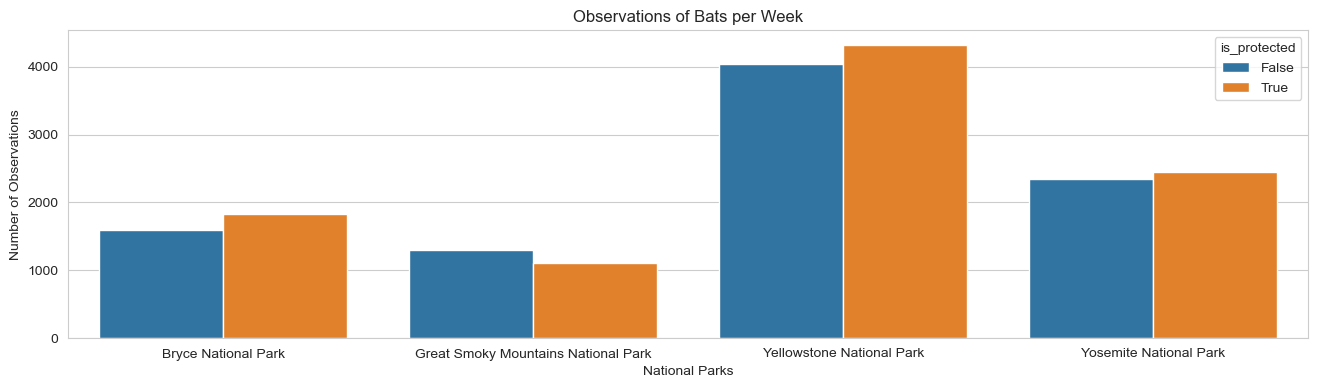

In [85]:
plt.figure(figsize=(16, 4))
sns.barplot(x=obs_by_park.park_name, y= obs_by_park.observations, hue=obs_by_park.is_protected)
plt.xlabel('National Parks')
plt.ylabel('Number of Observations')
plt.title('Observations of Bats per Week')
plt.show()